In [55]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.simplefilter("ignore")

# The goal of the Ecommerce Customer Data dataset is to:

Predict the Yearly Amount Spent
Using customer features like:
Time on App
Time on Website
Length of Membership
To understand and analyze patterns in customer spending.
Specific Objectives:
Identify Key Features: Determine which features (e.g., Time on App, Time on Website) have the most significant impact on yearly spending.
Develop Predictive Models: Build models (e.g., Linear Regression) to predict customer spending based on the provided features.
Customer Segmentation: Segment customers based on their spending behavior to offer targeted promotions or services.
Platform Performance Insights:
Understand whether the app or website contributes more to customer engagement and spending.
Inform decisions on where to focus investments for user experience improvements.
Outcome:
Provide actionable insights to the e-commerce platform to boost sales, optimize customer engagement, and improve platform usability.

In [56]:
df = pd.read_csv(r"C:\Users\SHRI\OneDrive\Desktop\DataScience_DataFiles\data\Ecommerce_customers.csv")

In [57]:
df

,\tEmail,Address,Avatar,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank TunnelWrightmouth, MI 82180-9605",Violet,12.66,39.58,4.08,587.95
1,hduke@hotmail.com,"4547 Archer CommonDiazchester, CA 06566-8576",DarkGreen,11.11,37.27,2.66,392.20
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582Cobbborough, DC ...",Bisque,11.33,37.11,4.10,487.55
3,riverarebecca@gmail.com,"1414 David ThroughwayPort Jason, OH 22070-1220",SaddleBrown,13.72,36.72,3.12,581.85
4,mstephens@davidson-herman.com,"14023 Rodriguez PassagePort Jacobville, PR 372...",MediumAquaMarine,12.80,37.54,4.45,599.41
...,...,...,...,...,...,...,...
495,lewisjessica@craig-evans.com,"4483 Jones Motorway Suite 872Lake Jamiefurt, U...",Tan,13.57,36.42,3.75,573.85
496,katrina56@gmail.com,"172 Owen Divide Suite 497West Richard, CA 19320",PaleVioletRed,11.70,37.19,3.58,529.05
497,dale88@hotmail.com,"0787 Andrews Ranch Apt. 633South Chadburgh, TN...",Cornsilk,11.50,38.33,4.96,551.62
498,cwilson@hotmail.com,"680 Jennifer Lodge Apt. 808Brendachester, TX 0...",Teal,12.39,36.84,2.34,456.47


In [58]:
df.shape

(500, 7)

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   	Email                500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Time on App           500 non-null    float64
 4   Time on Website       500 non-null    float64
 5   Length of Membership  500 non-null    float64
 6   Yearly Amount Spent   500 non-null    float64
dtypes: float64(4), object(3)
memory usage: 27.5+ KB


In [60]:
df.dtypes

\tEmail                  object
Address                  object
Avatar                   object
Time on App             float64
Time on Website         float64
Length of Membership    float64
Yearly Amount Spent     float64
dtype: object

In [61]:
df.isnull().sum()

\tEmail                 0
Address                 0
Avatar                  0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

In [62]:
numerical_cols = ['Time on App', 'Time on Website', 'Length of Membership', 'Yearly Amount Spent']
df[numerical_cols].skew()

Time on App            -0.088326
Time on Website         0.011819
Length of Membership   -0.106374
Yearly Amount Spent     0.034801
dtype: float64

In [63]:
df.columns

Index(['\tEmail', 'Address', 'Avatar', 'Time on App', 'Time on Website',
       'Length of Membership', 'Yearly Amount Spent'],
      dtype='object')

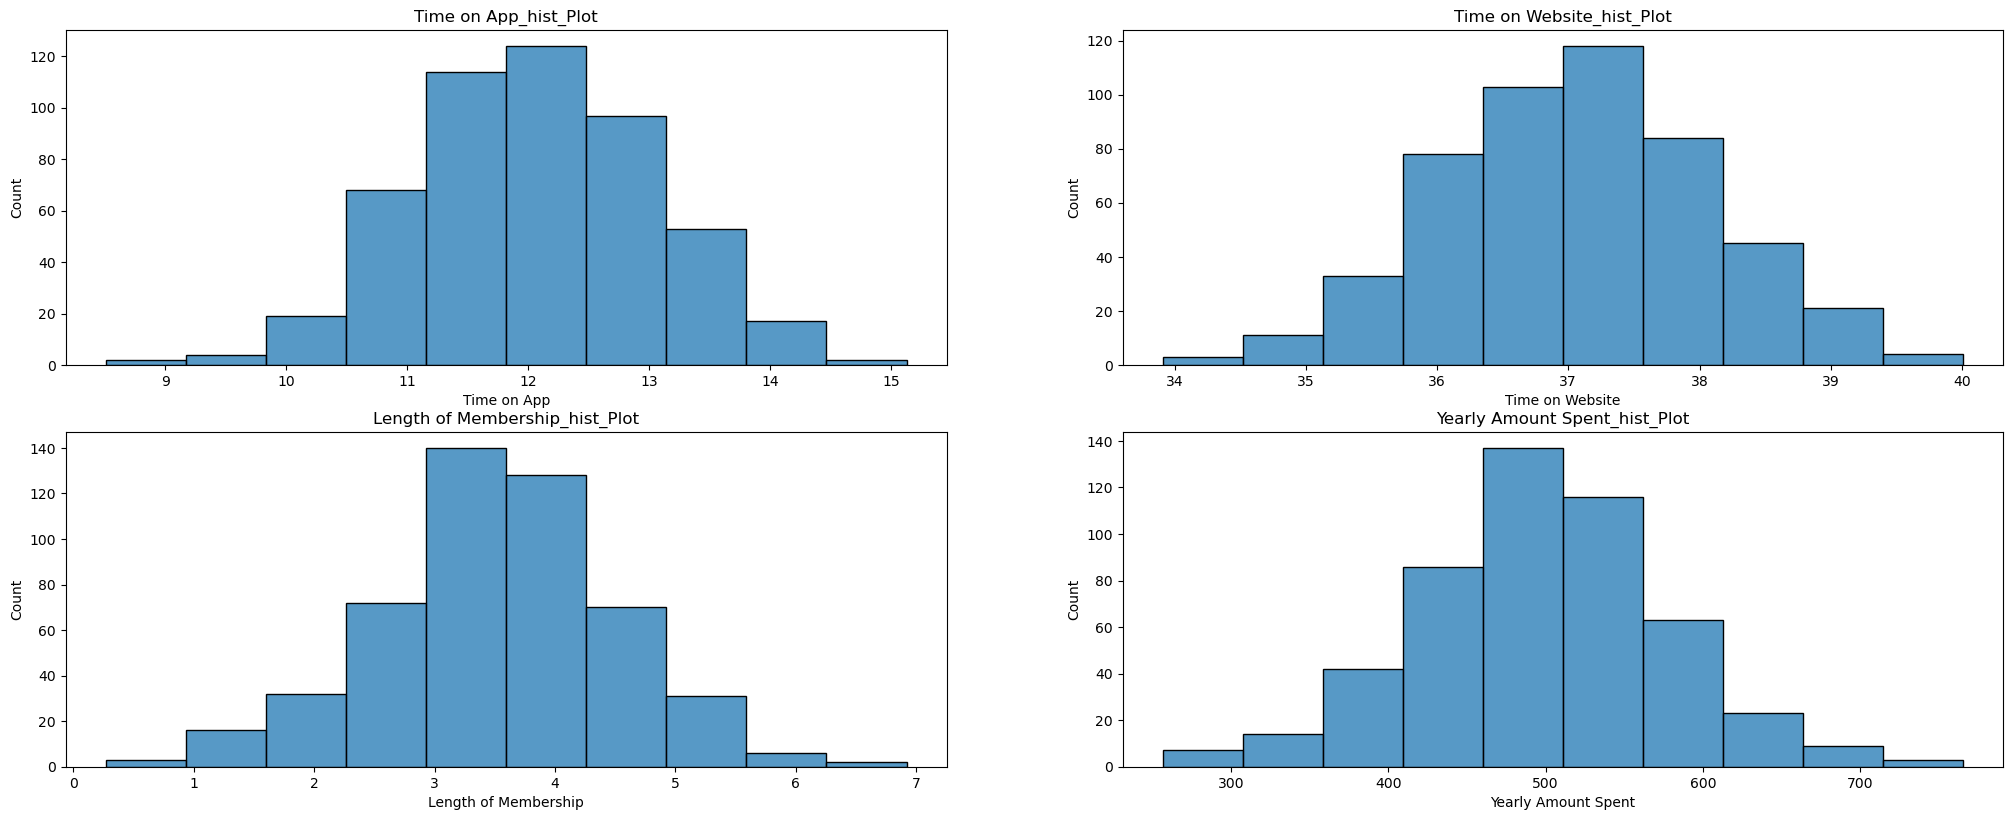

In [64]:
j=1
plt.figure(figsize=(25,20))
for i in range(len(numerical_cols)):
    plt.subplot(4,2,j)
    sns.histplot(data=df, bins = 10, x=numerical_cols[i])
    plt.title(f'{numerical_cols[i]}_hist_Plot')
    j=j+1
plt.show()

In [65]:
corr_data=df.corr(numeric_only=True)
corr_data

,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
Time on App,1.000000,0.082285,0.029240,0.499315
Time on Website,0.082285,1.000000,-0.047443,-0.002601
Length of Membership,0.029240,-0.047443,1.000000,0.809184
Yearly Amount Spent,0.499315,-0.002601,0.809184,1.000000


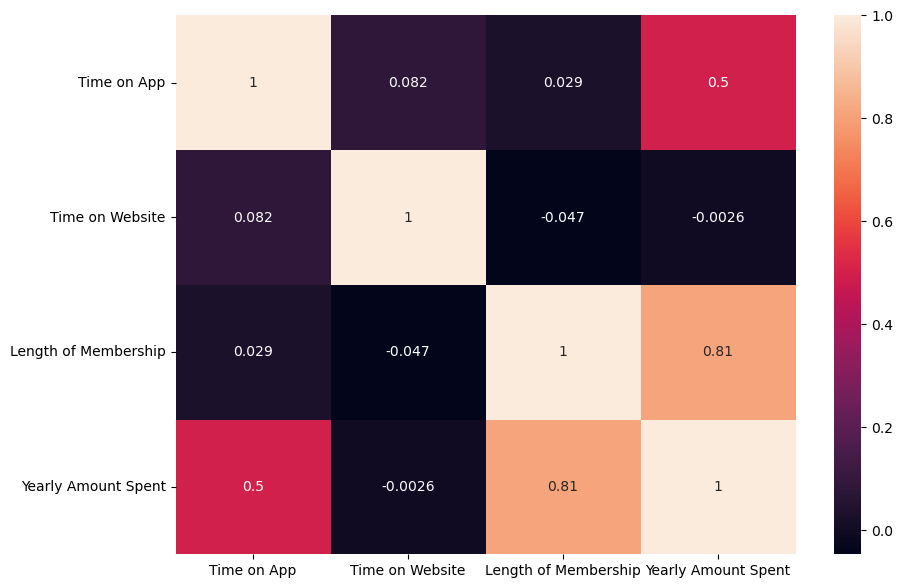

In [66]:
plt.figure(figsize=(10,7))
sns.heatmap(corr_data,annot=True)
plt.show()

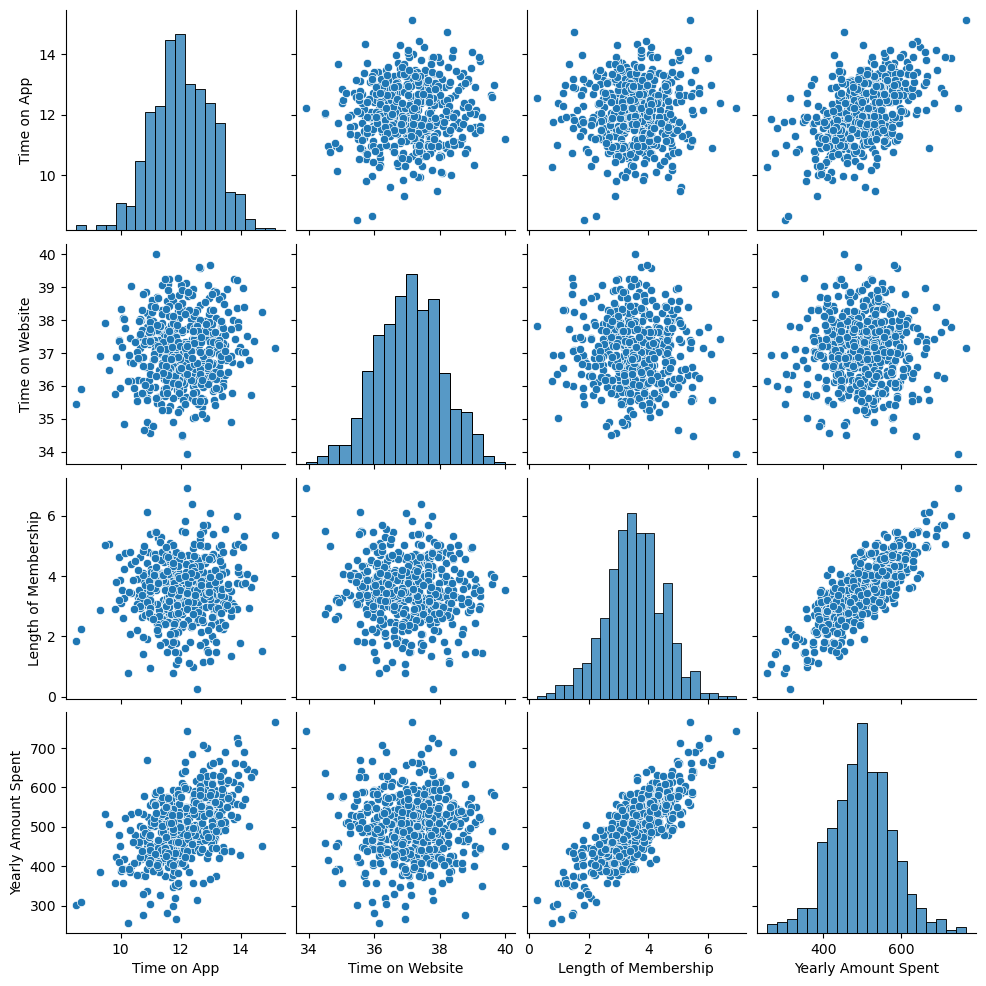

In [67]:
sns.pairplot(df)
plt.show()

**Observation**
- Based on this plot length of membership and yearly amout spent is highly correlated where both are increasing simultaneously

# Exploratory Data Analysis (EDA)

In [68]:
# now we work on data numericalsonly
data = df[['Time on App','Yearly Amount Spent', 'Time on Website', 'Length of Membership']]
data

,Time on App,Yearly Amount Spent,Time on Website,Length of Membership
0,12.66,587.95,39.58,4.08
1,11.11,392.20,37.27,2.66
2,11.33,487.55,37.11,4.10
3,13.72,581.85,36.72,3.12
4,12.80,599.41,37.54,4.45
...,...,...,...,...
495,13.57,573.85,36.42,3.75
496,11.70,529.05,37.19,3.58
497,11.50,551.62,38.33,4.96
498,12.39,456.47,36.84,2.34


In [69]:
data.mean()

Time on App              12.05262
Yearly Amount Spent     499.31424
Time on Website          37.06048
Length of Membership      3.53336
dtype: float64

In [70]:
data.median()

Time on App              11.980
Yearly Amount Spent     498.890
Time on Website          37.070
Length of Membership      3.535
dtype: float64

In [71]:
# Use scatterplots to explore the relationship between features like Time on App and Yearly Amount Spent.

<Axes: xlabel='Time on App', ylabel='Yearly Amount Spent'>

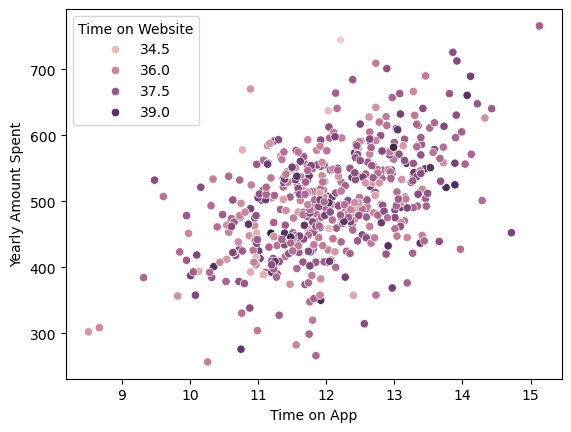

In [72]:
# Compare Time on Website vs. Time on App to understand their respective impacts on spending.

sns.scatterplot(x = 'Time on App', y = 'Yearly Amount Spent',hue = 'Time on Website', data = df)

<Axes: xlabel='Time on App', ylabel='Time on Website'>

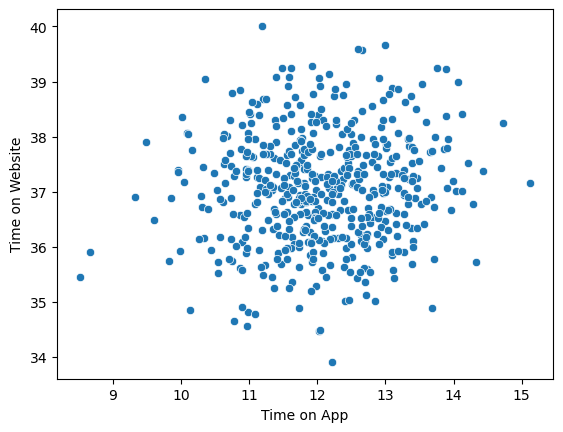

In [74]:
# Compare Time on Website vs. Time on App to understand their respective impacts on spending.

sns.scatterplot(x = 'Time on App', y = 'Time on Website', data = data)

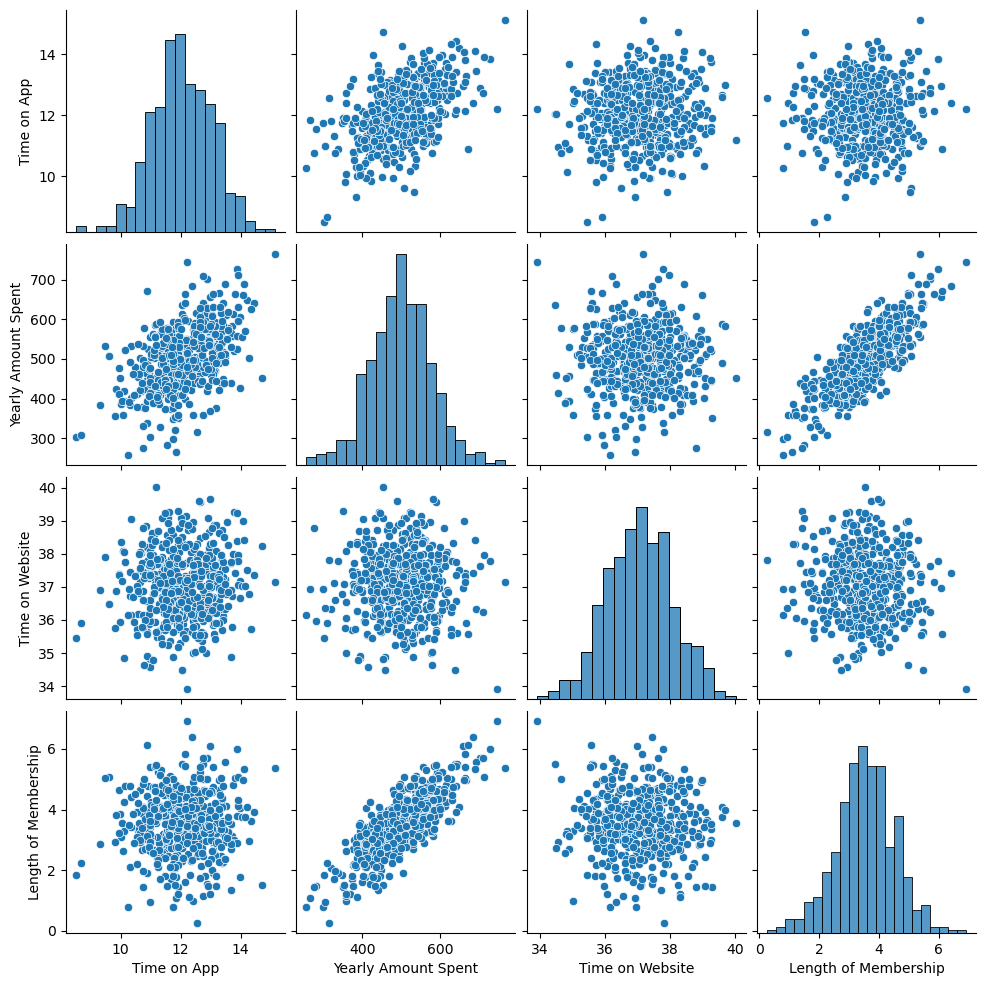

In [75]:
# Analyze which plot shows a more evident trend or stronger relationship.

sns.pairplot(data)
plt.show()

# Train Test Split

In [77]:
from sklearn.model_selection import train_test_split

In [78]:
# Define features (X) and target (y)
X = data[['Time on App', 'Time on Website', 'Length of Membership']]  # Features
y = data['Yearly Amount Spent']  # Target

In [96]:
# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)# Display the shapes of the resulting splits
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (400, 3)
Testing Features Shape: (100, 3)
Training Target Shape: (400,)
Testing Target Shape: (100,)


# Linear Regression

In [94]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the Linear Regression model
model = LinearRegression()

model.fit(X_train, y_train)

# Get the slope and intercept
slope = model.coef_[0]
intercept = model.intercept_
print(f"Slope (m): {slope}")
print(f"Intercept (c): {intercept}")

# Predict the target values for the testing data
y_pred = model.predict(X_test)


# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")



Slope (m): 37.99274284712039
Intercept (c): -199.87685478509815
Mean Squared Error: 806.8262850130459
R² Score: 0.8370629843717938


In [95]:
# Calculate RMSE
rmse = np.sqrt(mse)
print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 28.404687729546435
